# Bagging, Boosting and Stacking on Breast Cancer Dataset

This notebook demonstrates how to apply a Random Forest and other classifers to the Breast Cancer dataset using Python and scikit-learn. The notebook covers data loading, exploration, model training, evaluation, and hyperparameter tuning.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries for dataset, model, and evaluation
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot style
sns.set(style="whitegrid")


In [ ]:
# Load and explore the Breast Cancer dataset

# Load the dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')

# Display the first five rows of features
print("Features:")
display(X.head())

# Display basic statistics
print("Feature Statistics:")
display(X.describe())

# Display the target variable distribution
print("Target Distribution:")
display(y.value_counts())


Features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Feature Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Target Distribution:


,count
target,
1,357
0,212


In [ ]:
# Split the Data into Training and Testing Sets
# X: The feature matrix (independent variables).y: The target variable (dependent variable).
# test_size=0.2 and training_size=0.8
# random_state=42 set it to fixed number to ensure that every time you run this code, you will get the same split.
# stratify=y to ensure class distribution across train-test sets.

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


Random Forest model trained!
Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



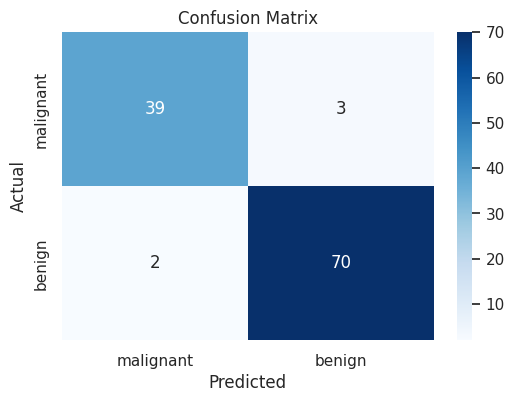

In [ ]:
# Build and Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100,   # number of trees
                                  random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained!")

# Make Predictions and Evaluate the Model
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
################# a random forest classifier ############################

from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

# Build and Train the Bagging Classifier using RF
# estimator=rf_model, using the trained random forest model as the base estimator
# n_estimators=10, # number of base estimators (trees in this case)

bagging_model_rf = BaggingClassifier(estimator=rf_model, n_estimators=10, random_state=42)   # n_estimators default = 10

# Train the model
bagging_model_rf.fit(X_train, y_train)

print("Bagging model trained using RF!")

# Make predictions on the test set
y_pred = bagging_model_rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


################# an extra trees classifier ############################
# It uses the same random subset of features method in selecting the best split at each branch in the tree. However, it also randomizes the discrimination threshold; where a
# decision tree normally chooses the most effective split between classes, ExtraTrees split at a random value.

bagging_model_extra = ExtraTreesClassifier(n_estimators=10, max_depth=None, random_state=0)

# Train the model
bagging_model_extra.fit(X_train, y_train)

print("Bagging model trained using extra trees!")

# Make predictions on the test set
y_pred = bagging_model_extra.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Bagging model trained using RF!
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[39  3]
 [ 2 70]]
Accuracy: 0.956140350877193
Bagging model trained using extra trees!
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[39  3]
 [ 2 70]]
Accuracy: 0.956140350877193


In [ ]:
#### using DT classifier only #####
bagging_model = DecisionTreeClassifier(max_depth=None,random_state=0)

################## Bagging Classifiers ###################################

################# a random patches/subspace classifier &  meta-estimators ############################
#The BaggingClassifier applies bagging to the KNeighborsClassifier (base model), meaning it trains multiple KNN models,
#each on a different random subset of the data.
# max_samples=0.5 --> each base model will be trained on only 50% of the training samples (randomly selected with replacement).This helps create diversity among the models.
# max_features=0.5 --> each base model will use only 50% of the total features (randomly selected). This reduces correlation among models and improves robustness.
bagging_model = BaggingClassifier(KNeighborsClassifier(), max_samples=0.5,max_features=0.5)   #max_samples/features=1.0 use all the samples/features

# Train the model
bagging_model.fit(X_train, y_train)

print("Bagging model trained!")

# Make predictions on the test set
y_pred = bagging_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Bagging model trained!
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.93      0.96      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Confusion Matrix:
 [[37  5]
 [ 3 69]]
Accuracy: 0.9298245614035088


In [ ]:
####################### testing random_state ####################

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load dataset
X, y = load_iris(return_X_y=True)

# Randomly split data (no random_state)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

# Randomly split data (with random_state

# Run again
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2)

# The two splits will be different!
print((X_train1 == X_train2).all())  # Output: False


False


## Conclusion

In this notebook, we have:

- Loaded and explored the Breast Cancer dataset (a binary classification problem)
- Split the dataset into training and testing sets
- Built and trained a Random Forest classifier
- Evaluated the model using accuracy, a classification report, and a confusion matrix
- Visualized the feature importances

Feel free to modify this notebook to experiment with other datasets or model parameters.


++++++++++++++++++++++ **Boosting** ++++++++++++++++++++++++++++++++

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.956140350877193


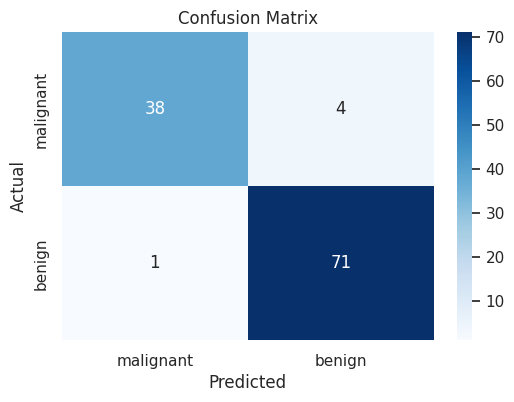

In [ ]:
#The Adaboost classifier

from sklearn.ensemble import AdaBoostClassifier

# Create an AdaBoost classifier
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators

# Train the AdaBoost model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred_ada))
#print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("Accuracy:", accuracy_score(y_test, y_pred_ada))

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred_ada)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.956140350877193


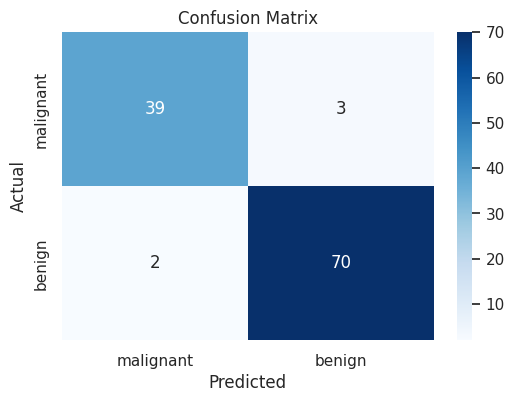

In [ ]:
######## Stacking classifier ###################

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define estimators for the stacking classifier
estimators = [
    ('rf', rf_model),
    ('ada', ada_model),
    ('bagging', bagging_model)
]

# Create the stacking classifier with a Logistic Regression final estimator
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions
y_pred_stacking = stacking_model.predict(X_test)

# Evaluate the stacking model
print(classification_report(y_test, y_pred_stacking))
print("Accuracy:", accuracy_score(y_test, y_pred_stacking))

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred_stacking)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
